# Descubrimiento del modelo de riesgo de ignición

**TFM · Sistema de detección de incendios · Galicia**

Este cuaderno reúne la fase de descubrimiento del proyecto: las preguntas que nos fuimos
haciendo, los experimentos con los que las respondimos y los caminos que cerramos. No es un
resumen de resultados sino el recorrido que llevó hasta el modelo actual, incluidos los
intentos que no funcionaron —que son varios y explican por qué el sistema final tiene la
forma que tiene.

## De dónde salen las cifras

Ninguna cifra de este cuaderno está escrita a mano. Todas se cargan de ficheros producidos
por ejecuciones reales, y cada celda documenta **qué script la generó y sobre qué datos**.
Se hace así, y no recalculando en el momento, por dos motivos: el entrenamiento completo son
horas de cómputo, y el datacubo de 86 millones de filas no está en el repositorio.

| Origen | Generado por | Dataset |
|---|---|---|
| `pipeline_*.csv` | `scripts/pipeline_definitivo.py` | EGIF 50 predictores, 2016–2023 |
| `busqueda_*.csv`, `seleccion_*.csv`, `estudio_muestreo.csv` | `scripts/` de `src/entrenamiento` | EGIF 47 predictores, 2019–2023 |
| `archive/firms_mikel/docs/technical/*.csv` | experimentación descartada | NASA FIRMS, 2019–2024 |

**Las tres familias no son intercambiables.** Provienen de datasets distintos y sus cifras no
se comparan entre sí sin decirlo. Cuando en el cuaderno aparezcan juntas, se avisa.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd()
if not (RAIZ / "docs").exists():
    RAIZ = RAIZ.parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

TECNICA = RAIZ / "docs" / "technical"
ARCHIVO = RAIZ / "archive" / "firms_mikel" / "docs" / "technical"

#: El cómputo en vivo exige el datacubo completo, que no está en el repositorio. Con `False`
#: el cuaderno se apoya solo en los resultados guardados y corre en segundos.
CALCULAR_EN_VIVO = False

pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

mpl.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10, "axes.titlesize": 11.5, "axes.titleweight": "medium",
    "axes.labelsize": 9.5, "legend.frameon": False,
})

TEAL, GRIS, OCRE = "#0F5F5C", "#8B9691", "#8A5A2B"


def cargar(nombre: str, origen: Path = TECNICA) -> pd.DataFrame:
    """Lee un CSV de resultados avisando con claridad si falta."""
    ruta = origen / nombre
    if not ruta.exists():
        raise FileNotFoundError(
            f"Falta {ruta.relative_to(RAIZ)}. Se genera ejecutando el script "
            f"correspondiente; ver la tabla de procedencia al inicio."
        )
    return pd.read_csv(ruta)


def pct(serie, decimales: int = 1) -> pd.Series:
    return (serie * 100).round(decimales).astype(str) + " %"


print(f"Raíz del proyecto: {RAIZ}")
print(f"Resultados vigentes:   {len(list(TECNICA.glob('*.csv')))} ficheros")
print(f"Resultados archivados: {len(list(ARCHIVO.glob('*.csv')))} ficheros")

Raíz del proyecto: C:\TFM\Sistema-deteccion-incendios
Resultados vigentes:   24 ficheros
Resultados archivados: 13 ficheros


---
## 1 · El problema y los datos

Para cada celda de un kilómetro cuadrado de Galicia y cada día, estimar el riesgo de que se
inicie un incendio. La dificultad no está en el modelo sino en la proporción: **de cada 6.500
parejas celda-día, arde una**. Un clasificador que dijera siempre «no» acertaría el 99,98 %
de las veces y sería inútil.

Eso condiciona todo lo que viene después: cómo se entrena, cómo se mide y qué significa un
resultado bueno.

In [2]:
contrato = cargar("pipeline_contrato.csv")
contrato

,clave,valor
0,predictores,50
1,años,"[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]"
2,filas_totales,86494122
3,contrato_temporal,No temporal shift; meteorological accumulation...
4,filas_descartadas,0
5,variables_ciclicas,[]
6,año_reservado,2023
7,grupo_actividad_humana,7
8,grupo_cobertura,9
9,grupo_meteorologia,22


El reparto temporal separa cuatro papeles, y el año de calibración es el detalle que suele
olvidarse: si el calibrador se ajusta sobre el mismo año con el que después se puntúa, ha
visto las etiquetas que se le piden predecir.

In [3]:
config = json.loads((TECNICA / "pipeline_definitivo_config.json").read_text(encoding="utf-8"))

reparto = pd.DataFrame([
    {"papel": "Entrenamiento", "años": ", ".join(map(str, config["años_entrenamiento"]))},
    {"papel": "Calibración", "años": str(config["año_calibracion"])},
    {"papel": "Validación", "años": str(config["año_validacion"])},
    {"papel": "Test ciego", "años": f"{config['año_reservado']} — sin abrir"},
])
print(reparto.to_string(index=False))
print(f"\nMuestreo de negativos: 1 de cada {config['modulo_muestreo']}")
print(f"Semilla: {config['semilla']}   ·   Réplicas bootstrap: {config['n_bootstrap']}")

        papel                         años
Entrenamiento 2016, 2017, 2018, 2019, 2020
  Calibración                         2021
   Validación                         2022
   Test ciego             2023 — sin abrir

Muestreo de negativos: 1 de cada 100
Semilla: 42   ·   Réplicas bootstrap: 1000


### Cómo se mide

La exactitud no sirve. Se usan tres métricas, y cada una responde una pregunta distinta:

- **Recall al 5 % de FPR** — si se vigila el 5 % del territorio, ¿qué fracción de igniciones
  cae dentro? Es la pregunta de quien tiene un presupuesto.
- **Recall en el 1 % diario** — dado que hoy es 12 de agosto, ¿se acierta *qué celdas*? No
  vale acertar que agosto es peor que enero: eso lo dice el calendario.
- **ROC-AUC dentro del día** — la misma idea expresada como área bajo la curva, calculada
  comparando solo celdas del mismo día.

Todas se acompañan de intervalos de confianza al 90 % por remuestreo sobre las igniciones.
Con 1.659 positivos, dos puntos de diferencia pueden ser ruido.

---
## 2 · ¿De dónde sale la señal?

La primera pregunta del descubrimiento: de las cincuenta variables disponibles, ¿cuáles
aportan de verdad?

La medida correcta no es la correlación de cada variable con el objetivo, porque eso ignora
las interacciones y los árboles viven de ellas. Se usa **importancia por permutación**: se
baraja una columna, se vuelve a puntuar y se mide cuánto empeora. Si no empeora, esa variable
no estaba aportando nada que el modelo usara.

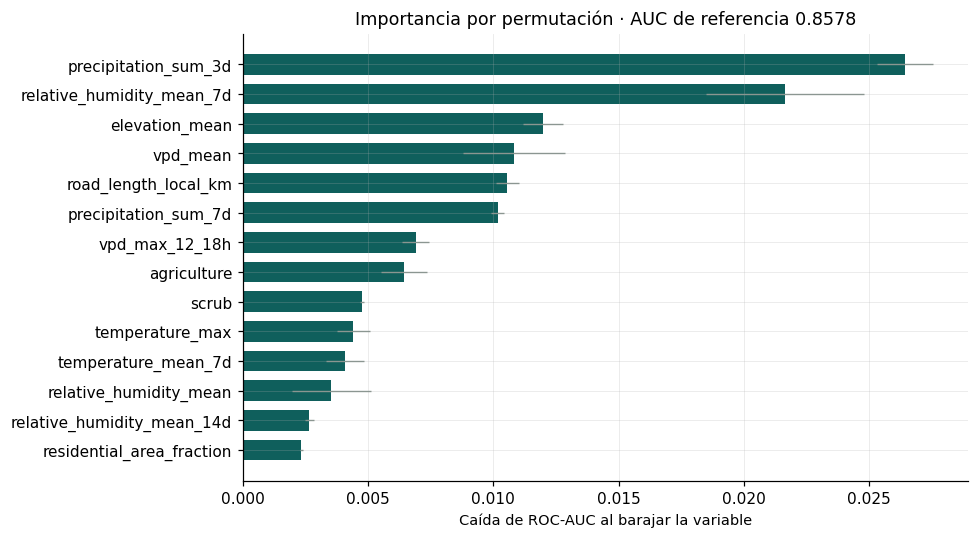

,variable,caida_media,caida_desv
0,precipitation_sum_3d,0.0265,0.0011
1,relative_humidity_mean_7d,0.0216,0.0031
2,elevation_mean,0.0120,0.0008
3,vpd_mean,0.0108,0.0020
4,road_length_local_km,0.0106,0.0005
5,precipitation_sum_7d,0.0102,0.0003
6,vpd_max_12_18h,0.0069,0.0005
7,agriculture,0.0064,0.0009
8,scrub,0.0048,0.0001
9,temperature_max,0.0044,0.0007


In [4]:
# Generado por: python scripts/pipeline_definitivo.py
# Dataset: EGIF 50 predictores, 2016-2023 · permutación sobre validación 2022
perm = cargar("importancia_permutacion.csv").sort_values("caida_media", ascending=False)

top = perm.head(14).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["variable"], top["caida_media"], xerr=top["caida_desv"],
        color=TEAL, height=0.7, error_kw={"ecolor": GRIS, "elinewidth": 0.9})
ax.set_xlabel("Caída de ROC-AUC al barajar la variable")
ax.set_title(f"Importancia por permutación · AUC de referencia {perm['auc_base'].iloc[0]:.4f}")
plt.tight_layout()
plt.show()

perm.head(10)[["variable", "caida_media", "caida_desv"]]

Tres lecturas:

**Manda el agua, no el calor.** Las dos primeras son precipitación acumulada a tres días y
memoria de humedad a siete. La temperatura máxima aparece en décimo lugar. El combustible se
seca acumulando días secos, no por un pico de calor puntual.

**La actividad humana es la quinta variable del modelo.** `road_length_local_km` —densidad de
carreteras *locales*, no principales—. Tiene lectura física directa: la mayoría de las
igniciones en Galicia son de causa humana, y no arrancan junto a las autovías sino en la red
secundaria, donde hay acceso al monte.

**La altitud es la cuarta.** No es meteorología ni actividad: es dónde está el combustible.

---
## 3 · ¿Cuántas variables hacen falta?

Sabiendo cuáles importan, la pregunta siguiente es cuántas conservar. Se responde con una
**curva de compromiso**: entrenar con las *k* mejores para una escalera de valores de *k* y
medir cada punto con su intervalo.

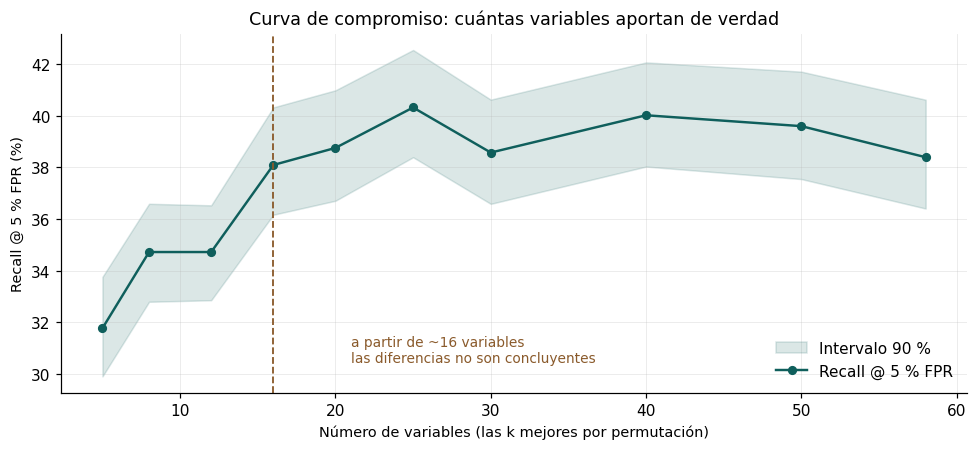

,k,recall_at_fpr5,ic_bajo,ic_alto
0,5,0.3177,0.2990,0.3376
1,8,0.3472,0.3279,0.3659
2,12,0.3472,0.3285,0.3653
3,16,0.3810,0.3617,0.4033
4,20,0.3876,0.3671,0.4099
5,25,0.4033,0.3840,0.4256
6,30,0.3858,0.3659,0.4063
7,40,0.4002,0.3803,0.4207
8,50,0.3960,0.3755,0.4171
9,58,0.3840,0.3641,0.4063


In [5]:
# Generado por: python scripts/seleccionar_variables.py
# Dataset: EGIF 47 predictores, 2019-2023 · validación sobre 2022 completo
curva = cargar("seleccion_curva.csv").sort_values("k")

fig, ax = plt.subplots()
ax.fill_between(curva["k"], curva["ic_bajo"] * 100, curva["ic_alto"] * 100,
                color=TEAL, alpha=0.15, label="Intervalo 90 %")
ax.plot(curva["k"], curva["recall_at_fpr5"] * 100, "o-", color=TEAL, lw=1.6, ms=5,
        label="Recall @ 5 % FPR")
ax.axvline(16, color=OCRE, ls="--", lw=1.2)
ax.annotate("a partir de ~16 variables\nlas diferencias no son concluyentes",
            xy=(16, ax.get_ylim()[0] + 1), xytext=(21, ax.get_ylim()[0] + 1.2),
            color=OCRE, fontsize=9)
ax.set_xlabel("Número de variables (las k mejores por permutación)")
ax.set_ylabel("Recall @ 5 % FPR (%)")
ax.set_title("Curva de compromiso: cuántas variables aportan de verdad")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

curva[["k", "recall_at_fpr5", "ic_bajo", "ic_alto"]]

La curva sube hasta unas dieciséis variables y a partir de ahí es **plana y no monótona**: hay
puntos con más variables que rinden peor que otros con menos. Esa no monotonía es la prueba
de que lo que se añade después es ruido — si aportara algo, la curva subiría aunque fuera poco.

La poda automática, aplicada antes de la curva, retira solo lo demostrablemente prescindible:
constantes, exceso de nulos y duplicados con correlación de Spearman por encima de 0,99.

In [6]:
poda = cargar("seleccion_poda.csv")
poda[["variable", "motivo", "evidencia"]]

,variable,motivo,evidencia
0,road_length_other_km,constante,1 valor(es) distinto(s)
1,temperature_max,duplicada,|Spearman| = 0.9989 con temperature_max_12_18h
2,relative_humidity_min_12_18h,duplicada,|Spearman| = 0.9947 con relative_humidity_min


Dos de esos descartes se confirmaron después por otra vía: el contrato del modelo final
**excluye explícitamente** `precipitation_sum` y `consecutive_dry_days`.

In [7]:
print("Variables excluidas del modelo final por el contrato:")
for v in config["excluir_del_modelo"]:
    print(f"  · {v}")

Variables excluidas del modelo final por el contrato:
  · precipitation_sum
  · consecutive_dry_days


---
## 4 · ¿Cuántos negativos hacen falta para entrenar?

Con una ignición por cada 6.500 celdas-día hay que descartar negativos o el gradiente no
aprende nada. La proporción que se venía usando —uno de cada veinticinco— era heredada y
nadie la había justificado, así que se puso a prueba: cuatro proporciones por cuatro formas
de elegir *qué* negativos conservar.

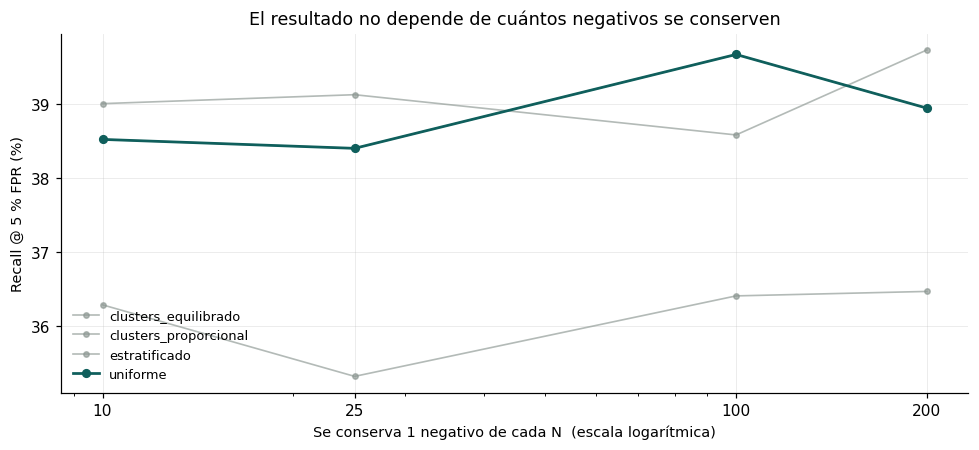

estrategia,clusters_equilibrado,clusters_proporcional,estratificado,uniforme
ratio,,,,
10,0.3629,0.3900,0.3852,0.3852
25,0.3532,0.3912,0.3840,0.3840
100,0.3641,0.3858,0.3966,0.3966
200,0.3647,0.3972,0.3894,0.3894


In [8]:
# Generado por: python scripts/estudiar_muestreo.py
# Dataset: EGIF 47 predictores, 2019-2023 · 16 combinaciones, validación sobre 2022 completo
muestreo = cargar("estudio_muestreo.csv")

fig, ax = plt.subplots()
for estrategia, grupo in muestreo.groupby("estrategia"):
    g = grupo.sort_values("ratio")
    destacada = estrategia == "uniforme"
    ax.plot(g["ratio"], g["recall"] * 100, "o-",
            color=TEAL if destacada else GRIS,
            lw=1.8 if destacada else 1.1, ms=5 if destacada else 3.5,
            alpha=1.0 if destacada else 0.65, label=estrategia)
ax.set_xscale("log")
ax.set_xticks(sorted(muestreo["ratio"].unique()))
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xlabel("Se conserva 1 negativo de cada N  (escala logarítmica)")
ax.set_ylabel("Recall @ 5 % FPR (%)")
ax.set_title("El resultado no depende de cuántos negativos se conserven")
ax.legend(loc="lower left", fontsize=8.5)
plt.tight_layout()
plt.show()

muestreo.pivot(index="ratio", columns="estrategia", values="recall")

**De 1:10 a 1:200 el recall se mueve entre 38,4 % y 39,7 %, con los intervalos solapados.**
Veinte veces menos datos y el mismo resultado; lo único que cambia es el tiempo de
entrenamiento, que pasa de cincuenta segundos a tres.

Sobre *qué* negativos elegir, ninguna estrategia mejora al azar. La estratificación por mes y
combustible resultó **idéntica** al muestreo uniforme —repartir con la misma tasa en todos los
estratos *es* muestreo uniforme— y el agrupamiento proporcional empata. La única que se separa
lo hace a peor: sobrerrepresentar las regiones raras del espacio de variables pierde unas tres
décimas en las cuatro proporciones, porque entrena sobre una distribución que no es la que el
modelo encontrará.

In [9]:
tiempos = muestreo[muestreo.estrategia == "uniforme"].sort_values("ratio")
print("Coste de entrenamiento con muestreo uniforme:\n")
print(tiempos[["ratio", "negativos", "recall", "segundos"]].to_string(index=False))
print(f"\nEl pipeline final adoptó 1:{config['modulo_muestreo']}.")

Coste de entrenamiento con muestreo uniforme:

 ratio  negativos  recall  segundos
    10    3243858  0.3852   49.0000
    25    1297543  0.3840   20.4000
   100     324386  0.3966    5.1000
   200     162193  0.3894    3.1000

El pipeline final adoptó 1:100.


---
## 5 · Los caminos que cerramos

Antes de llegar al modelo actual se probaron cuatro enfoques que se descartaron. Están aquí
porque un resultado negativo medido vale tanto como uno positivo: explica por qué el sistema
tiene la forma que tiene en lugar de otra.

> **Aviso de comparabilidad.** Estos experimentos se hicieron sobre **NASA FIRMS**, la fuente
> de target anterior, con distinta prevalencia y distinto conjunto de variables. Sus cifras
> sirven para comparar unas con otras *dentro de cada tabla*, nunca contra las del modelo
> actual.

### 5.1 · Red neuronal convolucional 3D

La idea era natural: si el dato es un cubo espacio-temporal, ¿por qué aplanarlo? Una Conv3D
en PyTorch podría aprovechar la vecindad espacial que la tabla destruye.

In [10]:
# Generado por: scripts/run_3d_nn_experiment.py (época FIRMS)
nn3d = cargar("nn_3d_vs_tabular_results.csv", ARCHIVO)
nn3d[["modelo", "roc_auc", "recall_at_fpr5"]]

,modelo,roc_auc,recall_at_fpr5
0,LightGBM Tabular 2D (Baseline),0.8377,0.3235
1,XGBoost Tabular 2D,0.8297,0.2745
2,Red Neuronal 3D Conv3D (PyTorch),0.8125,0.1275


**La red 3D detecta menos de la mitad de igniciones que un árbol tabular** (12,8 % frente a
32,4 %), con un coste de cómputo y una complejidad muy superiores.

Conviene fijarse en algo más: su `pr_auc` de 0,179 y su Brier de 0,094 parecen mejores que los
de los árboles, y no lo son. Se evaluó sobre un conjunto con prevalencia distinta, y ambas
métricas dependen de la prevalencia. Es exactamente el error que motivó que el protocolo
actual evalúe siempre sobre la población completa.

### 5.2 · Ensamble de tres modelos

Combinar LightGBM, XGBoost y CatBoost por promedio de rangos.

In [11]:
# Generado por: scripts/run_advanced_ensemble_experiment.py (época FIRMS)
ensamble = cargar("advanced_ensemble_results_2023.csv", ARCHIVO)
ensamble[["modelo", "roc_auc", "recall_at_fpr5", "brier_score"]]

,modelo,roc_auc,recall_at_fpr5,brier_score
0,LightGBM Avanzado,0.8264,0.3333,0.0017
1,XGBoost Avanzado,0.8327,0.2353,0.0014
2,CatBoost Classifier,0.8155,0.2059,0.0028
3,Ensamble Blending (SOTA Tabular),0.8299,0.2549,0.3305


**El ensamble es peor que LightGBM solo** (25,5 % frente a 33,3 %). Y su Brier de 0,33 frente
a 0,0017 delata el problema de fondo: promediar rangos no produce probabilidades, así que el
ensamble destruyó la calibración. En un sistema que tiene que emitir niveles de riesgo, eso
lo descarta por sí solo.

### 5.3 · Penalizar los falsos negativos

El manual dice que ante clases desbalanceadas hay que dar más peso a la minoritaria. Se probó
con coste asimétrico y con *focal weight*.

In [12]:
# Generado por: scripts/run_advanced_techniques_experiment.py (época FIRMS)
tecnicas = cargar("advanced_techniques_results.csv", ARCHIVO)
tecnicas[["modelo", "roc_auc", "recall_at_fpr5"]]

,modelo,roc_auc,recall_at_fpr5
0,LightGBM Standard,0.7568,0.2574
1,LightGBM Cost-Sensitive (20x FN),0.7629,0.1683
2,LightGBM + Calibración Isotónica,0.7410,0.2376


**Penalizar los falsos negativos empeora el recall en nueve puntos** (16,8 % frente a 25,7 %).

Es la conclusión más repetida del proyecto, y llegó por tres caminos independientes: aquí, en
el estudio de muestreo del apartado 4, y en la búsqueda de hiperparámetros, donde el peso de
clase resultó ser el segundo parámetro más influyente **con signo negativo** en los dos
modelos de boosting. Los valores ganadores rondaron 5 y 12, frente a los ~324 que exigiría la
compensación completa.

> En este problema el desbalanceo se trata **quitando negativos**, no reponderándolos. Hacer
> las dos cosas es corregir dos veces lo mismo.

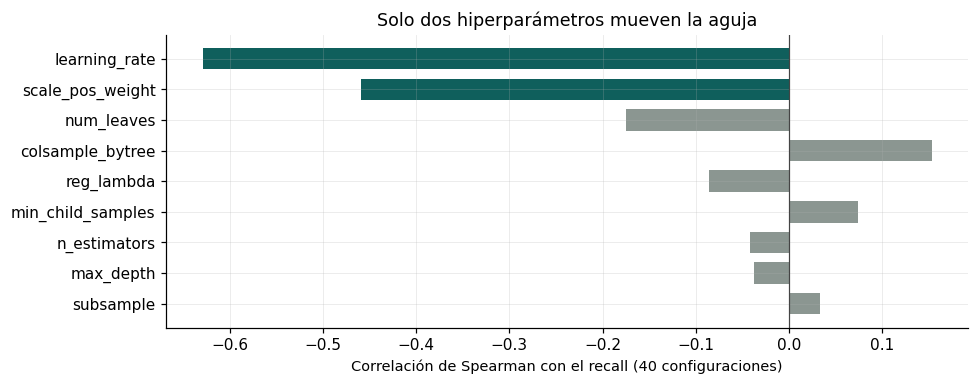

In [13]:
busqueda = cargar("busqueda_lightgbm.csv")
parametros = ["learning_rate", "scale_pos_weight", "num_leaves", "min_child_samples",
              "reg_lambda", "n_estimators", "subsample", "colsample_bytree", "max_depth"]
correlaciones = (busqueda[parametros + ["recall_medio"]]
                 .corr(method="spearman")["recall_medio"]
                 .drop("recall_medio")
                 .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 3.6))
colores = [TEAL if abs(v) > 0.3 else GRIS for v in correlaciones]
ax.barh(correlaciones.index[::-1], correlaciones.values[::-1], color=colores[::-1], height=0.7)
ax.axvline(0, color="#444", lw=0.8)
ax.set_xlabel("Correlación de Spearman con el recall (40 configuraciones)")
ax.set_title("Solo dos hiperparámetros mueven la aguja")
plt.tight_layout()
plt.show()

---
## 6 · Comparación de modelos

Cuatro familias sobre exactamente los mismos datos: dos de *boosting*, una de *bagging* y una
lineal como referencia.

In [14]:
# Generado por: python scripts/pipeline_definitivo.py
# Dataset: EGIF 50 predictores, 2016-2023 · validación sobre 2022 completo
modelos = cargar("pipeline_modelos.csv")
n_pos = int(modelos["n_positives"].iloc[0])

tabla = modelos[["modelo", "roc_auc", "recall_at_fpr5", "recall_ci90_low", "recall_ci90_high",
                 "recall_at_top1%_daily", "roc_auc_dentro_del_dia"]].copy()
tabla["igniciones"] = (modelos["recall_at_fpr5"] * n_pos).round().astype(int)
tabla.sort_values("recall_at_fpr5", ascending=False)

,modelo,roc_auc,recall_at_fpr5,recall_ci90_low,recall_ci90_high,recall_at_top1%_daily,roc_auc_dentro_del_dia,igniciones
0,lightgbm,0.8659,0.3966,0.3767,0.4171,0.0766,0.7431,658
1,xgboost,0.8519,0.3574,0.3394,0.3774,0.0711,0.7321,593
2,random_forest,0.8362,0.3400,0.3213,0.3580,0.0711,0.6903,564
3,logistic_regression,0.8438,0.3098,0.2911,0.3285,0.0398,0.7011,514


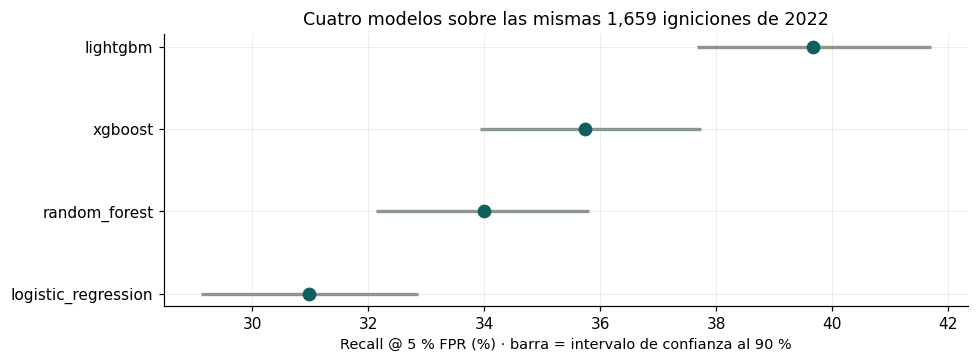

In [15]:
orden = modelos.sort_values("recall_at_fpr5")
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hlines(orden["modelo"], orden["recall_ci90_low"] * 100, orden["recall_ci90_high"] * 100,
          color=GRIS, lw=2.2)
ax.plot(orden["recall_at_fpr5"] * 100, orden["modelo"], "o", color=TEAL, ms=8)
ax.set_xlabel("Recall @ 5 % FPR (%) · barra = intervalo de confianza al 90 %")
ax.set_title(f"Cuatro modelos sobre las mismas {n_pos:,} igniciones de 2022")
plt.tight_layout()
plt.show()

### La comparación correcta es pareada

Los cuatro modelos se evalúan sobre **los mismos** incendios, así que comparar sus intervalos
por separado cuenta dos veces la varianza que comparten y declara «no concluyente»
diferencias que sí lo son. La comparación válida remuestrea los incendios una vez por réplica
y acumula la **diferencia**, acompañada del contraste de McNemar sobre los casos discordantes.

In [16]:
pareado = cargar("pipeline_pareado.csv")
comp = pareado[(pareado["metrica"] == "recall@fpr5") &
               (pareado["modelo_b"] != "definitivo") &
               (pareado["modelo_a"] != "definitivo")].copy()
comp["par"] = comp["modelo_a"] + "  vs  " + comp["modelo_b"]
comp[["par", "diferencia", "dif_ci90_low", "dif_ci90_high", "mcnemar_p",
      "solo_a", "solo_b", "veredicto"]].sort_values("diferencia", ascending=False)

,par,diferencia,dif_ci90_low,dif_ci90_high,mcnemar_p,solo_a,solo_b,veredicto
0,lightgbm vs logistic_regression,0.0868,0.0693,0.1037,0.0000,234,90,lightgbm mejor
1,lightgbm vs random_forest,0.0567,0.0386,0.0754,0.0000,231,137,lightgbm mejor
2,xgboost vs logistic_regression,0.0476,0.0265,0.0675,0.0002,255,176,xgboost mejor
3,lightgbm vs xgboost,0.0392,0.0223,0.0555,0.0002,180,115,lightgbm mejor
4,random_forest vs logistic_regression,0.0301,0.0084,0.0500,0.0197,246,196,random_forest mejor
5,xgboost vs random_forest,0.0175,-0.0030,0.0398,0.1804,233,204,no concluyente


Las columnas `solo_a` y `solo_b` son la lectura más directa que existe: **cuántas igniciones
caza un modelo que al otro se le escapan**. LightGBM detecta 234 que la regresión logística
pierde, y pierde 90 que ella sí encuentra.

Un resultado cambió respecto de una comparación anterior del equipo. Sobre el dataset de
2019–2023, LightGBM y XGBoost empataban (diferencia de 0,54 puntos, p = 0,49). Con el
histórico ampliado a 2016 la diferencia emerge y se vuelve concluyente:

In [17]:
lgb_xgb = pareado[(pareado["metrica"] == "recall@fpr5") &
                  (pareado["modelo_a"] == "lightgbm") &
                  (pareado["modelo_b"] == "xgboost")].iloc[0]

print(f"  diferencia .......... {lgb_xgb['diferencia'] * 100:+.2f} puntos")
print(f"  IC 90 % ............. [{lgb_xgb['dif_ci90_low'] * 100:+.2f}, "
      f"{lgb_xgb['dif_ci90_high'] * 100:+.2f}]")
print(f"  McNemar ............. p = {lgb_xgb['mcnemar_p']:.4f}")
print(f"  discordantes ........ {int(lgb_xgb['solo_a'])} solo LightGBM, "
      f"{int(lgb_xgb['solo_b'])} solo XGBoost")
print(f"  veredicto ........... {lgb_xgb['veredicto']}")
print("\n  Más datos convirtieron un empate aparente en una diferencia real.")

  diferencia .......... +3.92 puntos
  IC 90 % ............. [+2.23, +5.55]
  McNemar ............. p = 0.0002
  discordantes ........ 180 solo LightGBM, 115 solo XGBoost
  veredicto ........... lightgbm mejor

  Más datos convirtieron un empate aparente en una diferencia real.


---
## 7 · ¿Cuánto cuesta predecir con un día de antelación?

Esta es la pregunta que decide qué clase de sistema es el proyecto. Un modelo que usa la
meteorología **del propio día** del incendio describe lo que ya está pasando; uno que usa solo
la del día anterior **predice**. La segunda es la útil, y la duda era cuánto se pierde.

In [18]:
# Generado por: python scripts/pipeline_definitivo.py
circ = cargar("pipeline_circularidad.csv")
circ[["escenario", "n_variables", "recall_at_fpr5", "recall_ci90_low", "recall_ci90_high",
      "roc_auc_dentro_del_dia"]]

,escenario,n_variables,recall_at_fpr5,recall_ci90_low,recall_ci90_high,roc_auc_dentro_del_dia
0,completa (incluye el día T),50,0.3912,0.3713,0.4105,0.7400
1,amplia,40,0.3623,0.3424,0.3803,0.7413
2,pronóstico (solo T-1),36,0.3954,0.3761,0.4159,0.7344


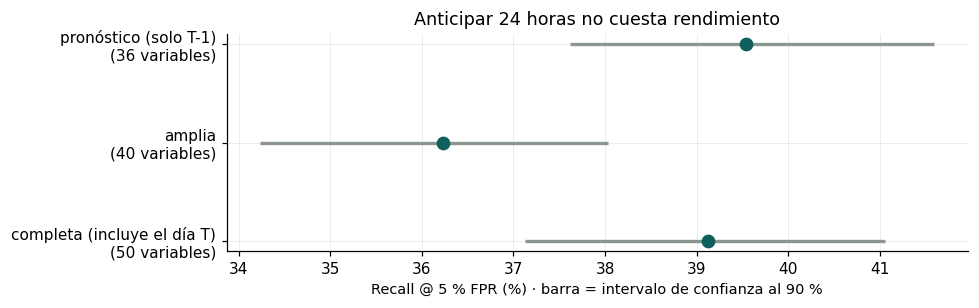

In [19]:
fig, ax = plt.subplots(figsize=(9, 2.9))
y = np.arange(len(circ))
ax.hlines(y, circ["recall_ci90_low"] * 100, circ["recall_ci90_high"] * 100, color=GRIS, lw=2.2)
ax.plot(circ["recall_at_fpr5"] * 100, y, "o", color=TEAL, ms=8)
ax.set_yticks(y)
ax.set_yticklabels([f"{e}\n({n} variables)" for e, n in
                    zip(circ["escenario"], circ["n_variables"])])
ax.set_xlabel("Recall @ 5 % FPR (%) · barra = intervalo de confianza al 90 %")
ax.set_title("Anticipar 24 horas no cuesta rendimiento")
plt.tight_layout()
plt.show()

**El escenario de pronóstico, que usa solo información disponible la víspera y catorce
variables menos, rinde igual que el completo.** 39,54 % frente a 39,12 %, con los intervalos
prácticamente superpuestos.

Es un resultado con consecuencias de diseño: si anticipar es gratis, el sistema **debe** ser
de previsión y no de diagnóstico. Un mapa que dice dónde puede arder mañana permite desplegar
medios; uno que describe el riesgo de hoy llega tarde.

El escenario intermedio, que retira también los acumulados y las medias móviles, sí pierde:
**2,9 puntos respecto del escenario completo**. La memoria meteorológica de días previos es
información legítima y disponible en producción; retirarla es prudencia excesiva.

> La columna `caida_recall` del fichero mide contra el modelo de referencia de 50 variables
> (39,66 %), no contra el escenario completo de esta misma tabla (39,12 %). Por eso ahí figura
> 3,4 y aquí 2,9: son la misma pérdida medida desde dos puntos de partida distintos.

---
## 8 · Contra el estándar: el Fire Weather Index

La comparación que da sentido al proyecto. El FWI es el índice canadiense que utilizan los
servicios europeos de protección civil, y el sistema de referencia europeo (CEMS) lo publica
a diario. Si un modelo entrenado no lo supera con claridad, no compensa el esfuerzo.

In [20]:
# Generado por: python scripts/pipeline_definitivo.py
fwi = cargar("pipeline_fwi.csv")
mejor = modelos.sort_values("recall_at_fpr5", ascending=False).iloc[0]

comparativa = pd.DataFrame([
    {"sistema": f"Modelo ({mejor['modelo']})", "recall": mejor["recall_at_fpr5"],
     "roc_auc": mejor["roc_auc"], "igniciones": round(mejor["recall_at_fpr5"] * n_pos)},
    *[{"sistema": f["variante"], "recall": f["recall_at_fpr5"], "roc_auc": f["roc_auc"],
       "igniciones": round(f["recall_at_fpr5"] * n_pos)} for _, f in fwi.iterrows()],
])
comparativa["igniciones"] = comparativa["igniciones"].astype(int)
comparativa

,sistema,recall,roc_auc,igniciones
0,Modelo (lightgbm),0.3966,0.8659,658
1,FWI Van Wagner 1 km,0.2393,0.8095,397
2,FWI oficial CEMS,0.2242,0.8068,372


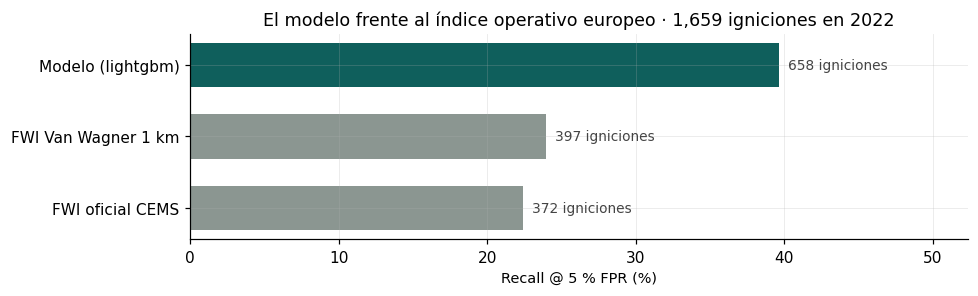

Ventaja del modelo sobre cada variante del FWI:

  FWI Van Wagner 1 km    +15.73 puntos  (+261 igniciones al año)
  FWI oficial CEMS       +17.24 puntos  (+286 igniciones al año)


In [21]:
fig, ax = plt.subplots(figsize=(9, 2.8))
colores = [TEAL] + [GRIS] * len(fwi)
ax.barh(comparativa["sistema"][::-1], comparativa["recall"][::-1] * 100,
        color=colores[::-1], height=0.62)
for i, (_, fila) in enumerate(comparativa[::-1].iterrows()):
    ax.text(fila["recall"] * 100 + 0.6, i, f"{fila['igniciones']:,} igniciones",
            va="center", fontsize=9, color="#444")
ax.set_xlabel("Recall @ 5 % FPR (%)")
ax.set_xlim(0, comparativa["recall"].max() * 100 * 1.32)
ax.set_title(f"El modelo frente al índice operativo europeo · {n_pos:,} igniciones en 2022")
plt.tight_layout()
plt.show()

print("Ventaja del modelo sobre cada variante del FWI:\n")
for _, f in fwi.iterrows():
    print(f"  {f['variante']:<22} {f['ventaja_del_modelo'] * 100:+.2f} puntos  "
          f"({int(f['igniciones_adicionales']):+,} igniciones al año)")

**Entre 261 y 286 igniciones más al año que el estándar operativo europeo**, con el mismo
coste de vigilancia. Ese es el argumento de utilidad del proyecto, y está medido contra una
referencia externa y publicada, no contra un baseline propio.

---
## 9 · Dónde falla el modelo

Un cuaderno de descubrimiento que solo enseñe lo que funciona no sirve. Estas son las tres
debilidades medidas.

### 9.1 · Fuera de temporada no acierta

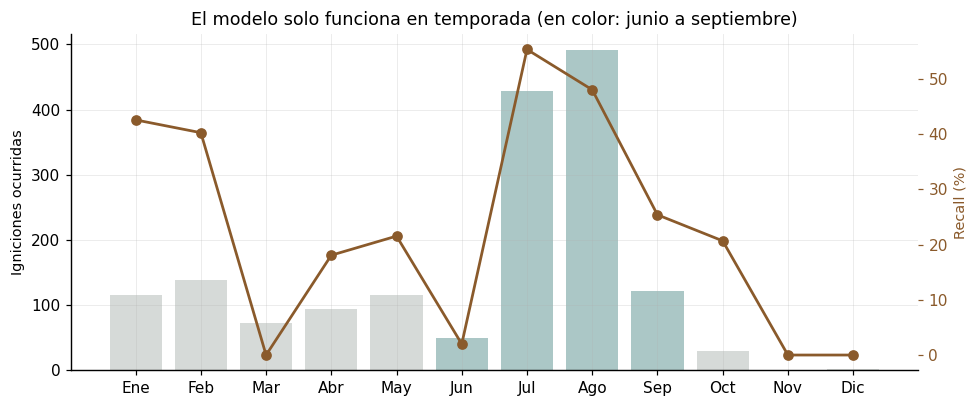

,nombre,igniciones,detectadas,recall
0,Ene,115,49,0.4261
1,Feb,139,56,0.4029
2,Mar,72,0,0.0000
3,Abr,94,17,0.1809
4,May,116,25,0.2155
5,Jun,50,1,0.0200
6,Jul,428,237,0.5537
7,Ago,491,236,0.4807
8,Sep,122,31,0.2541
9,Oct,29,6,0.2069


In [22]:
# Generado por: python scripts/pipeline_definitivo.py
meses = cargar("errores_por_mes.csv")
nombres = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
meses["nombre"] = meses["mes"].map(lambda m: nombres[int(m) - 1])
temporada = set(config["meses_temporada"])

fig, ax1 = plt.subplots(figsize=(9, 3.8))
colores = [TEAL if m in temporada else GRIS for m in meses["mes"]]
ax1.bar(meses["nombre"], meses["igniciones"], color=colores, alpha=0.35, label="Igniciones")
ax1.set_ylabel("Igniciones ocurridas")
ax2 = ax1.twinx()
ax2.plot(meses["nombre"], meses["recall"] * 100, "o-", color=OCRE, lw=1.8, ms=6,
         label="Recall")
ax2.set_ylabel("Recall (%)", color=OCRE)
ax2.tick_params(axis="y", colors=OCRE)
ax2.grid(False)
ax1.set_title("El modelo solo funciona en temporada (en color: junio a septiembre)")
plt.tight_layout()
plt.show()

meses[["nombre", "igniciones", "detectadas", "recall"]]

**En marzo hubo 72 igniciones y el modelo no detectó ninguna.** En junio, 50 igniciones y una
sola detectada. En julio y agosto, en cambio, supera el 48 %.

La explicación es que el modelo aprende sobre todo la estacionalidad meteorológica, y en
marzo las condiciones no se parecen a las de un día de incendio de verano. Pero las 72
igniciones de marzo ocurrieron: son en su mayoría quemas agrícolas fuera de época, un
fenómeno de causa humana que la meteorología no anticipa.

Es una limitación real de cara a un sistema operativo, que tendría que avisar todo el año.

### 9.2 · Los incendios que se escapan son los grandes

In [23]:
errores = cargar("pipeline_errores.csv")
errores.rename(columns={"media_detectadas": "media si se detecta",
                        "media_perdidas": "media si se escapa"})

,variable,media si se detecta,media si se escapa,diferencia
0,temperature_max_12_18h,24.9642,21.9867,2.9775
1,relative_humidity_min_12_18h,45.5479,52.6481,-7.1002
2,wind_speed_max_12_18h,12.4789,13.5282,-1.0493
3,precipitation_sum,0.3197,1.4493,-1.1296
4,consecutive_dry_days,11.0365,5.2507,5.7857
5,elevation_mean,423.2946,479.6999,-56.4053
6,scrub,0.2364,0.2741,-0.0377
7,road_length_km,5.7131,4.1056,1.6075
8,burned_area_ha,12.0779,43.1728,-31.0949
9,mes,6.4529,5.9600,0.4928


Los que se escapan ocurren en zonas **más altas** (480 m frente a 423), **más húmedas** (52,6 %
frente a 45,5 % de humedad mínima), con **menos carreteras** (4,1 km frente a 5,7) y tras
**menos días secos** (5,3 frente a 11,0).

Y sobre todo: **son los más grandes.** Superficie media de 43 ha frente a 12 ha. El modelo
falla justo en los incendios que más importan.

In [24]:
objetivo = cargar("pipeline_target.csv")
objetivo[["definicion", "igniciones", "roc_auc", "recall_at_fpr5",
          "recall_ci90_low", "recall_ci90_high"]]

,definicion,igniciones,roc_auc,recall_at_fpr5,recall_ci90_low,recall_ci90_high
0,todas las igniciones,1659,0.8659,0.3966,0.3767,0.4171
1,superficie ≥ 1 ha,351,0.8659,0.3818,0.3419,0.4245
2,superficie ≥ 10 ha,106,0.8701,0.3585,0.2830,0.4340
3,superficie ≥ 100 ha,29,0.8679,0.2759,0.1379,0.4138
4,grandes incendios (≥500 ha),12,0.8355,0.2500,0.0833,0.5000


Reentrenando con definiciones de objetivo cada vez más restrictivas, el recall cae de 39,7 %
a 25 % al pasar de todas las igniciones a los grandes incendios de 500 hectáreas. El ROC-AUC,
en cambio, aguanta en torno a 0,84: el modelo sigue **ordenando** bien, pero acertar el corte
operativo con doce casos al año es otra cosa. Los intervalos lo dicen sin ambigüedad —para
los grandes incendios va de 8 % a 50 %.

### 9.3 · La discriminación dentro del día es la debilidad estructural

In [25]:
espacial = cargar("pipeline_espacial.csv")
espacial[["banda", "celdas", "igniciones", "roc_auc", "recall_at_fpr5",
          "roc_auc_dentro_del_dia"]]

,banda,celdas,igniciones,roc_auc,recall_at_fpr5,roc_auc_dentro_del_dia
0,0,5961,646,0.8205,0.2601,0.5920
1,1,5943,442,0.8370,0.2896,0.6705
2,2,5877,253,0.8295,0.2490,0.6557
3,3,5901,166,0.8422,0.2711,0.6361
4,4,5919,152,0.8320,0.2961,0.5869


Separando el territorio en cinco bandas espaciales, el ROC-AUC global se mantiene entre 0,82
y 0,84 en todas — el modelo no depende de una zona concreta. Pero el **ROC-AUC dentro del
día** baja hasta 0,59 en las bandas extremas.

La causa está identificada: al convertir el cubo en tabla, **cada fila desconoce sus celdas
vecinas**. Un incendio a cinco kilómetros el día anterior no aparece en ninguna variable.
Acertar el día es fácil con meteorología; acertar la celda es un problema espacial que la
representación actual no puede resolver.

---
## 10 · Del riesgo a la operación

Un modelo que devuelve un número entre cero y uno no sirve a una brigada. Hace falta traducir
esa puntuación a niveles con volumen de alertas predecible, y para eso la probabilidad tiene
que estar **calibrada**: cuando el sistema dice 5 %, debe arder una de cada veinte.

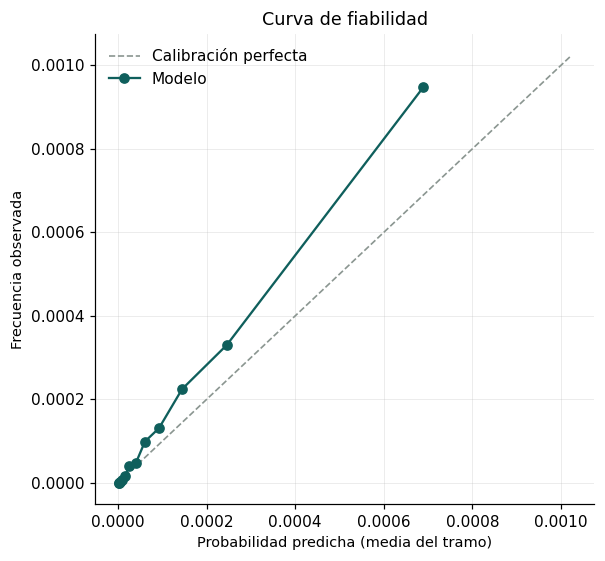

,bin,pred_media,obs_frecuencia,n
6,6,0.0000,0.0000,900364
7,7,0.0001,0.0001,900364
8,8,0.0001,0.0001,900363
9,9,0.0001,0.0002,900364
10,10,0.0002,0.0003,900364
11,11,0.0007,0.0009,900364


In [26]:
fiabilidad = cargar("pipeline_fiabilidad.csv")

fig, ax = plt.subplots(figsize=(5.6, 5.2))
lim = max(fiabilidad["pred_media"].max(), fiabilidad["obs_frecuencia"].max()) * 1.08
ax.plot([0, lim], [0, lim], "--", color=GRIS, lw=1.1, label="Calibración perfecta")
ax.plot(fiabilidad["pred_media"], fiabilidad["obs_frecuencia"], "o-", color=TEAL, ms=6, lw=1.5,
        label="Modelo")
ax.set_xlabel("Probabilidad predicha (media del tramo)")
ax.set_ylabel("Frecuencia observada")
ax.set_title("Curva de fiabilidad")
ax.legend()
plt.tight_layout()
plt.show()

fiabilidad.tail(6)

La curva sigue la diagonal, así que las probabilidades tienen significado. Sobre esa base se
construyen los cuatro niveles:

In [27]:
riesgo = cargar("pipeline_riesgo.csv")
umbrales = json.loads((TECNICA / "umbrales_riesgo.json").read_text(encoding="utf-8"))

print("Umbrales de probabilidad calibrada:")
for nivel, valor in umbrales.items():
    print(f"  {nivel.capitalize():<10} > {valor:.6f}")
print()
riesgo

Umbrales de probabilidad calibrada:
  Moderado   > 0.000288
  Alto       > 0.000768
  Extremo    > 0.001377



,nivel,celdas_dia,porcentaje_territorio,igniciones,incidencia,veces_sobre_nivel_bajo
0,Bajo,9723928,0.9000,735,0.0001,1.0000
1,Moderado,864349,0.0800,526,0.0006,8.1000
2,Alto,162066,0.0150,238,0.0015,19.4000
3,Extremo,54022,0.0050,160,0.0030,39.2000


Esta es la tabla que se lleva a un puesto de mando. **El nivel Extremo cubre el 0,5 % del
territorio y contiene 160 de las 1.659 igniciones**, con una incidencia 39 veces superior a
la del nivel Bajo. Vigilar el 2 % del territorio —Alto más Extremo— captura 398 igniciones,
casi una de cada cuatro.

---
## 11 · ¿Es reproducible?

Los modelos de *boosting* con paralelismo completo no garantizan resultados idénticos entre
ejecuciones. Antes de publicar cualquier cifra hay que saber cuánto se mueve por azar.

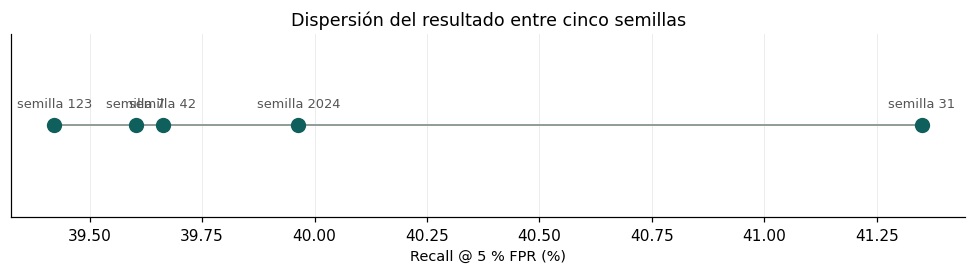

  recall entre 39.42 % y 41.35 %   ·   rango 1.93 puntos
  ROC-AUC entre 0.8659 y 0.8671

  Configuración: deterministic=True, force_row_wise=True


In [28]:
semillas = cargar("pipeline_semilla.csv")

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.hlines(0, semillas["recall_at_fpr5"].min() * 100, semillas["recall_at_fpr5"].max() * 100,
          color=GRIS, lw=1.2)
ax.plot(semillas["recall_at_fpr5"] * 100, np.zeros(len(semillas)), "o", color=TEAL, ms=9)
for _, f in semillas.iterrows():
    ax.annotate(f"semilla {int(f['semilla'])}", (f["recall_at_fpr5"] * 100, 0),
                textcoords="offset points", xytext=(0, 12), ha="center", fontsize=8.5,
                color="#555")
ax.set_yticks([])
ax.set_xlabel("Recall @ 5 % FPR (%)")
ax.set_title("Dispersión del resultado entre cinco semillas")
plt.tight_layout()
plt.show()

rango = (semillas["recall_at_fpr5"].max() - semillas["recall_at_fpr5"].min()) * 100
print(f"  recall entre {semillas['recall_at_fpr5'].min() * 100:.2f} % y "
      f"{semillas['recall_at_fpr5'].max() * 100:.2f} %   ·   rango {rango:.2f} puntos")
print(f"  ROC-AUC entre {semillas['roc_auc'].min():.4f} y {semillas['roc_auc'].max():.4f}")
print(f"\n  Configuración: deterministic={config['hiperparametros'].get('deterministic')}, "
      f"force_row_wise={config['hiperparametros'].get('force_row_wise')}")

El rango entre semillas es de unos dos puntos, **del mismo orden que las diferencias que se
quieren detectar**. De ahí que toda comparación del proyecto se haga con intervalos y con el
test pareado, y no comparando cifras sueltas.

---
## 12 · Qué aprendimos

### Lo que funciona

| | |
|---|---|
| Modelo | LightGBM sobre la representación tabular del datacubo |
| Recall al 5 % del territorio | ~39,7 % · unas 658 de 1.659 igniciones |
| Frente al estándar europeo | **+261 a +286 igniciones al año** |
| Anticipación de 24 horas | **sin coste medible** |

### Lo que no funciona, y está medido

- **Red convolucional 3D**: menos de la mitad de recall que un árbol tabular.
- **Ensamble de tres modelos**: peor que LightGBM solo y con la calibración rota.
- **Penalizar los falsos negativos**: nueve puntos peor. Confirmado por tres vías.
- **Más variables**: por encima de dieciséis no hay diferencia concluyente.
- **Más negativos**: de 1:200 a 1:10 tampoco.

El hilo común es que **el límite no está en la técnica sino en la información disponible**.
Cinco intentos de mejorar por el lado del modelo no movieron la aguja; lo único que produjo un
salto grande fue añadir datos nuevos —la actividad humana de OpenStreetMap, hoy la quinta
variable del sistema.

### Lo que falta

**Contexto espacial.** Es la debilidad estructural del apartado 9.3 y la línea con más
recorrido: incorporar la vecindad de cada celda dentro de su propia fila —condiciones de las
celdas contiguas, igniciones recientes en el entorno, distancia al fuego más próximo— sin
abandonar la representación tabular.

**Cobertura fuera de temporada.** Marzo tiene 72 igniciones y un recall del 0 %. Un sistema
operativo tiene que avisar los doce meses.

In [29]:
print("=" * 74)
print("PROCEDENCIA DE LAS CIFRAS DE ESTE CUADERNO")
print("=" * 74)
procedencia = pd.DataFrame([
    {"apartado": "1, 2, 6-11", "script": "scripts/pipeline_definitivo.py",
     "dataset": "EGIF 50 var · 2016-2023"},
    {"apartado": "3", "script": "scripts/seleccionar_variables.py",
     "dataset": "EGIF 47 var · 2019-2023"},
    {"apartado": "4", "script": "scripts/estudiar_muestreo.py",
     "dataset": "EGIF 47 var · 2019-2023"},
    {"apartado": "5.4", "script": "scripts/buscar_hiperparametros.py",
     "dataset": "EGIF 47 var · 2019-2023"},
    {"apartado": "5.1-5.3", "script": "scripts/run_*_experiment.py (archivado)",
     "dataset": "NASA FIRMS · 2019-2024"},
])
print(procedencia.to_string(index=False))
print("\nLas tres familias de dataset no son comparables entre sí.")
print("Cada apartado se interpreta dentro de su propia fuente.")

PROCEDENCIA DE LAS CIFRAS DE ESTE CUADERNO
  apartado                                  script                 dataset
1, 2, 6-11          scripts/pipeline_definitivo.py EGIF 50 var · 2016-2023
         3        scripts/seleccionar_variables.py EGIF 47 var · 2019-2023
         4            scripts/estudiar_muestreo.py EGIF 47 var · 2019-2023
       5.4       scripts/buscar_hiperparametros.py EGIF 47 var · 2019-2023
   5.1-5.3 scripts/run_*_experiment.py (archivado)  NASA FIRMS · 2019-2024

Las tres familias de dataset no son comparables entre sí.
Cada apartado se interpreta dentro de su propia fuente.
